# Moving Window Functions

**Moving window functions** compute a statistic (mean, std, correlation, ...) over a sliding subset of a time series, rather than over the whole thing at once. This is one of the main tools for **smoothing** noisy or gappy time series data, and for tracking how a statistic changes over time instead of collapsing it to a single number.

Despite the name, this notebook actually covers three related-but-different tools:

| Tool | Window behavior |
|---|---|
| `.rolling(window)` | Fixed-size window that slides forward one step at a time |
| `.expanding()` | Window that starts small and grows to include everything seen so far |
| `.ewm(...)` | No fixed window at all — every past observation contributes, but recent ones are weighted more heavily (exponential decay) |

All three:
- Are called *before* an aggregation, the same way `groupby` and `resample` are — e.g. `series.rolling(...).mean()`, not `series.mean().rolling(...)`.
- Automatically **exclude missing data** from the aggregation, the same way `.mean()` / `.sum()` / etc. do normally.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

> **Bug fix:** the import above used to read `import matplotlib as plt`, which binds `plt` to the top-level `matplotlib` package instead of the `pyplot` submodule. Most `.plot()` calls in this notebook still worked despite that, because pandas triggers its own internal `import matplotlib.pyplot` behind the scenes — but a bare `plt.legend()` later in this notebook raised `TypeError: 'module' object is not callable`, since `matplotlib.legend` is just a module (containing the `Legend` class), not a callable function. Fixed to the standard `import matplotlib.pyplot as plt`.

We'll work with daily closing prices for a few stocks. `.resample("B").ffill()` reindexes the data onto a **business-day** frequency and forward-fills any gaps (e.g. missing rows in the source file) — this guarantees an evenly-spaced index before applying moving-window functions, which assume ordered, non-duplicated timestamps:

In [2]:
close_px_all = pd.read_csv("/Users/bmart231/DS/examples/stock_px.csv", parse_dates=True, index_col=0)

close_px = close_px_all[["AAPL", "MSFT", "XOM"]]

close_px = close_px.resample("B").ffill()

## The `rolling` operator

`rolling` behaves similarly to `resample` and `groupby`: you call it on a Series or DataFrame with a `window` (a number of periods), and it returns an object you then call an aggregation on — `.mean()`, `.std()`, `.sum()`, `.corr()`, etc.

<Axes: >

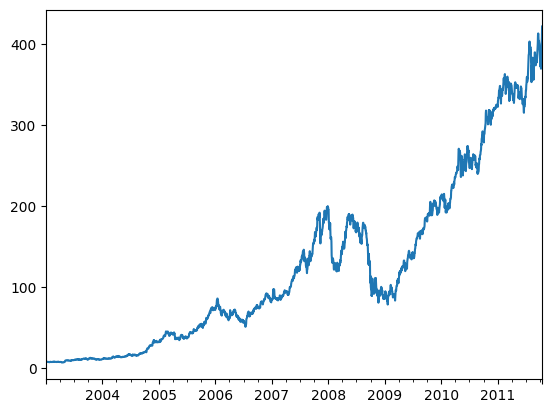

In [3]:
close_px["AAPL"].plot()

<Axes: >

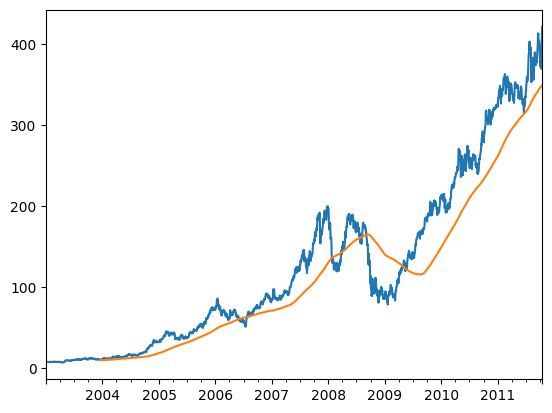

In [4]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot()


`rolling(250)` is similar in behavior to `groupby`, but instead of grouping by a key, it creates an object representing a 250-day sliding window at every point in the series. Aggregating with `.mean()` on it gives Apple's 250-day moving average — the value at each date is the mean of that date and the preceding 249 days.

**By default, `rolling` requires every value in the window to be non-`NA`** to produce a result — which has an important consequence: the first `window - 1` entries will always be `NaN`, since there aren't yet enough prior observations to fill the window. For `rolling(250)`, that's the first 249 rows.

You can relax this with `min_periods`: it sets the *minimum* number of non-`NA` observations required (instead of demanding a full window), so you start getting results earlier — at the cost of those early values being noisier estimates, since they're based on fewer observations than the target window size.

In [5]:
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()

std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

## The `expanding` operator

An **expanding window** is like a rolling window whose size keeps growing: instead of always looking back a fixed number of periods, it includes *every* observation from the start of the series through the current point. Practically, `series.expanding().mean()` at row `i` equals `series[:i+1].mean()` — a running/cumulative mean, computed through the same rolling-style API (so it gets the same NA-handling, works column-wise on DataFrames, etc., as `rolling` and `ewm`).

Applying it to `std250` (which already has leading `NaN`s from the earlier rolling calculation) carries those same leading gaps, then produces a running average of the volatility from that point onward:

In [6]:
expanding_mean = std250.expanding().mean()

expanding_mean[5:15]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.011723
2003-01-20    0.012226
2003-01-21    0.012339
2003-01-22    0.012328
Freq: B, Name: AAPL, dtype: float64

Calling a moving window function on a DataFrame applies the transformation to each column independently — the plot below shows three separately-smoothed lines, one per stock:

<Axes: >

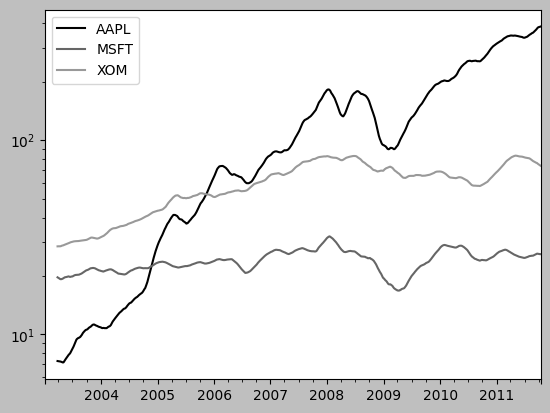

In [7]:
plt.style.use('grayscale')

close_px.rolling(60).mean().plot(logy=True)

## Time-based (offset) windows

So far, `window` has meant "a fixed *number of periods*" (e.g., the last 250 rows). `rolling` also accepts a **time offset string** instead — the same kind of string you'd pass to `resample` (`"20D"`, `"5min"`, etc.) — meaning "a window spanning the last 20 calendar days," regardless of how many rows that covers.

This distinction matters most for **irregular time series** (missing days, unevenly spaced timestamps): a period-count window like `rolling(20)` always covers exactly 20 rows, however much wall-clock time they span, while an offset window like `rolling("20D")` always covers exactly 20 days, however many (or few) rows fall inside that span. On our business-day-frequency data the two are nearly equivalent, but they'd diverge on data with gaps.

For example, here's a 20-day rolling mean:

In [8]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


## Exponentially Weighted Functions

Instead of a fixed window with every observation weighted equally, an **exponentially weighted (EW)** statistic applies a *decay factor*: every observation contributes to every future value, but its weight shrinks the further back in time it is. Because recent points are weighted more heavily, an EW statistic "adapts" faster to changes than an equal-weighted moving average does — there's no hard cutoff where old data suddenly drops out of the window entirely.

pandas' `ewm` operator (**e**xponentially **w**eighted **m**oving) works alongside `rolling` and `expanding`. You specify the decay using **one** of these (mutually exclusive) arguments:

| Argument | Meaning |
|---|---|
| `span` | Comparable to a simple moving average window of this size — the most common choice, used below |
| `halflife` | Number of periods for a weight to decay to half its value |
| `com` | Center of mass — an alternate, less intuitive parameterization |
| `alpha` | The smoothing factor directly, `0 < alpha <= 1` |

They're all convertible into each other (e.g. `alpha = 2 / (span + 1)`); `span` is usually the easiest to reason about since it's directly comparable to a rolling window size.

Below, a 30-day simple moving average of Apple's stock price is compared against an EW moving average with `span=30`:

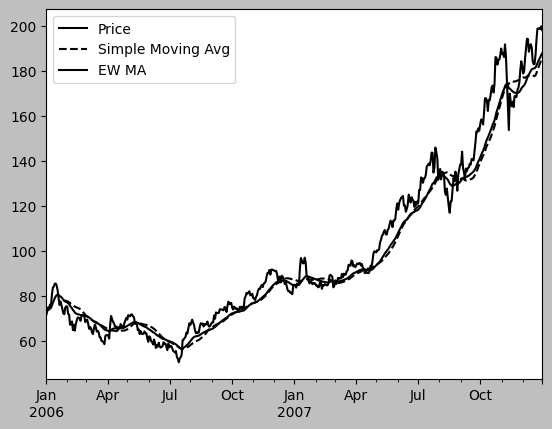

In [9]:
aapl_px = close_px["AAPL"]["2006":"2007"]

ma30 = aapl_px.rolling(30, min_periods=20).mean()

ewma30 = aapl_px.ewm(span=30).mean()

aapl_px.plot(style="k-", label="Price")

ma30.plot(style="k--", label="Simple Moving Avg")

ewma30.plot(style="k-", label="EW MA")

plt.legend()


## Binary Moving Window Functions

Some statistics — correlation and covariance, most notably — need **two** time series, not one. A common example: how correlated is a stock's returns with a benchmark index like the S&P 500?

First, convert prices to percent changes (returns), since correlating raw price *levels* is usually far less meaningful than correlating their period-over-period *changes*:

In [10]:
spx_px = close_px_all["SPX"]

spx_rets = spx_px.pct_change()

returns = close_px.pct_change()

Once you've called `rolling` on a Series, the `.corr()` aggregation computes a **rolling correlation against another series** (`spx_rets`), instead of the usual single-series statistic:

<Axes: >

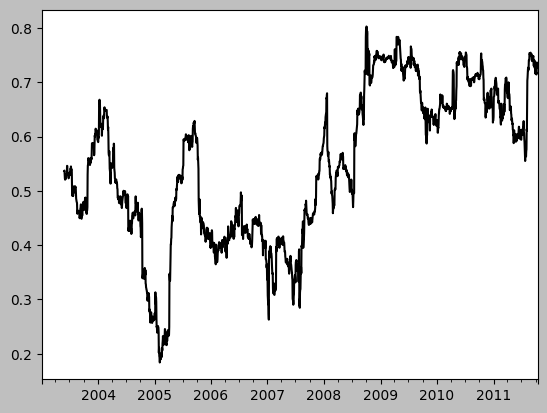

In [11]:
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)

corr.plot()

To get the rolling correlation of the S&P 500 against *several* stocks at once, you don't need to loop — call `rolling` directly on the multi-column DataFrame and pass `spx_rets` to `.corr()`. Each column is correlated against `spx_rets` independently, giving back a DataFrame with one rolling-correlation column per stock:

<Axes: >

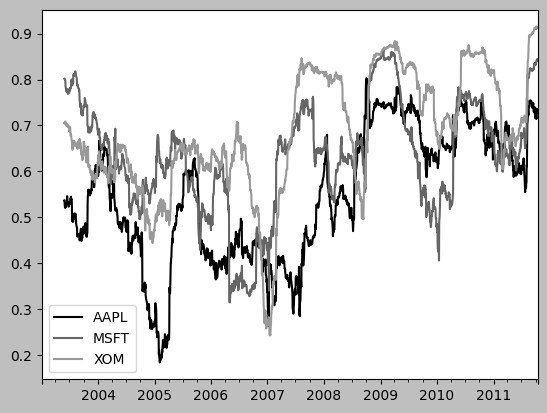

In [12]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)

corr.plot()

## User-Defined Moving Window Functions

`.rolling(...).apply(func)` lets you plug in your own function to run over each window. The one hard requirement: **`func` must reduce each window down to a single scalar value** (the way `.mean()` or `.std()` do) — it can't return an array or a Series.

For example, `rolling(...).quantile(q)` gives you a sample quantile, but there's no built-in for the reverse question: "what percentile does *this specific value* fall at, within the window?" `scipy.stats.percentileofscore` answers exactly that, so we wrap it in a one-line function and pass it to `.apply()`:

> **Performance note:** `.apply()` runs `func` once per window via a plain Python-level loop, so it's noticeably slower than the built-in aggregations (`.mean()`, `.std()`, ...), which are vectorized. For large windows/series, `rolling(...).apply(func, engine="numba")` can help if `func` is numba-compatible.

<Axes: >

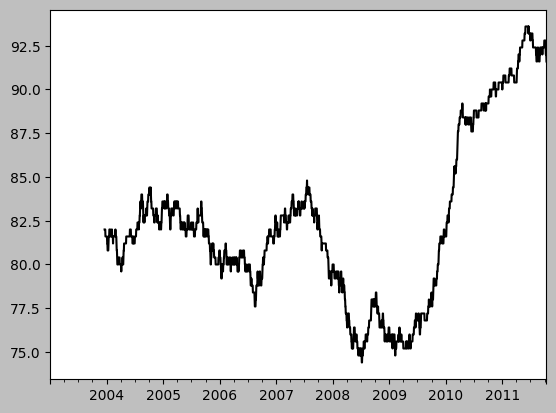

In [13]:
from scipy.stats import percentileofscore

def score_at_2percent(x):
    return percentileofscore(x, 0.02)

result = returns["AAPL"].rolling(250).apply(score_at_2percent)

result.plot()

## Recap

| Tool | What it does | Typical use |
|---|---|---|
| `.rolling(window)` | Fixed-size sliding window — `window` rows, or a time-offset string like `"20D"` | Smoothing, moving averages, moving std/corr |
| `.expanding()` | Window grows from the start of the series to the current point | Cumulative/running statistics |
| `.ewm(span=... / halflife=... / com=... / alpha=...)` | No fixed cutoff — all history contributes, weighted by recency | Statistics that should "adapt" quickly to recent changes |
| `.rolling(...).corr(other)` / `.cov(other)` | Rolling statistic between *two* series | Rolling correlation to a benchmark |
| `.rolling(...).apply(func)` | Your own function, one scalar result per window | Custom rolling statistics not built into pandas |

**Things that tend to trip people up:**
- The first `window - 1` rows of a rolling result are `NaN` by default — use `min_periods` to get (noisier) values earlier instead of waiting for a full window.
- A period-count window (`rolling(250)`) counts *rows*; a time-offset window (`rolling("20D")`) counts *elapsed time* — they only agree when the data is regularly spaced with no gaps.
- `expanding()` and `ewm()` don't take a `window` argument at all — there's no fixed size to specify.
- `.apply(func)` must return a single scalar per window, and runs a Python-level loop — much slower than the built-in aggregations.
- `import matplotlib as plt` is a bug, not a style choice — always use `import matplotlib.pyplot as plt` (see the callout earlier in this notebook).